In [1]:
import os, sys

os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ.setdefault("NUMEXPR_NUM_THREADS", "1")
os.environ.setdefault("VECLIB_MAXIMUM_THREADS", "1")

sys.path.append("/mnt/lareaulab/reliscu/programs/FGP_2024")

import Chronocell
from Chronocell.inference import Trajectory
from Chronocell.mixtures import PoissonMixtureSS
from Chronocell.utils import *
from Chronocell.plotting import *
import scipy.stats as stats
from scipy.interpolate import UnivariateSpline, RBFInterpolator
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cmasher as cmr
from tqdm import tqdm
import copy
import anndata as ad

os.chdir("/mnt/lareaulab/reliscu/projects/Chronocell/analyses/janssens_2025_preprint")

In [2]:
# Ref: https://github.com/pachterlab/FGP_2024/blob/main/notebooks/Forebrain.ipynb

In [3]:
adata = ad.read_h5ad("data/janssens_2025_CellRanger_Velocyto_counts_eLNP.h5ad")

In [4]:
adata = adata[~adata.obs['newClustersTmp'].isin(["Other cDC1s"])].copy()

In [5]:
gene_names = adata.var_names

In [6]:
from sklearn.decomposition import PCA
total_UMI = adata.X.toarray().sum(axis=1)
r = total_UMI/np.mean(total_UMI)
pca = PCA(n_components=3)
x = pca.fit_transform(np.log(1+adata.X.toarray()/total_UMI[:,None]*np.mean(total_UMI)))

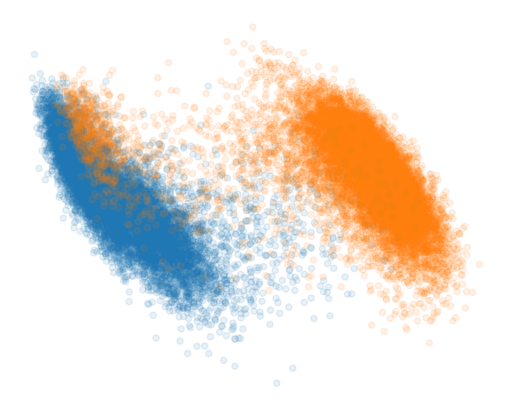

In [7]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder() 
clusters = le.fit_transform(adata.obs['Condition'])
Clusters = set(clusters)

tab_colors = plt.cm.tab10(np.arange(10))
fig, ax = plt.subplots(1,1,figsize=(5,4))
ax.scatter(-x[:,0],-x[:,1],c=tab_colors[clusters],alpha=.1,s=20);
ax.set_frame_on(False)
plt.xticks([]);
plt.yticks([]);

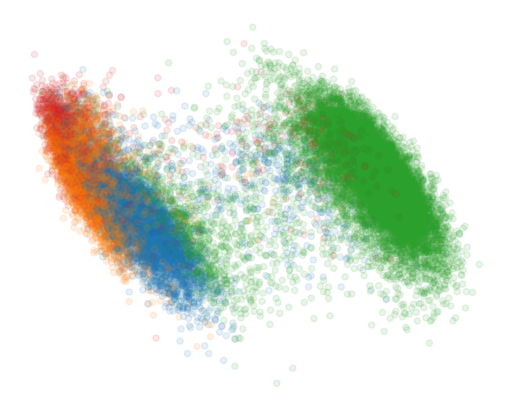

In [8]:
clusters = le.fit_transform(adata.obs['newClustersTmp'])
Clusters = set(clusters)

tab_colors = plt.cm.tab10(np.arange(10))
fig, ax = plt.subplots(1,1,figsize=(5,4))
ax.scatter(-x[:,0],-x[:,1],c=tab_colors[clusters],s=20,alpha=.1);
ax.set_frame_on(False)
plt.xticks([]);
plt.yticks([]);

In [9]:
set(adata.obs['newClustersTmp'])

{'Early mature cDC1s',
 'Immature cDC1s',
 'Late mature cDC1s',
 'Proliferating cDC1s'}

## Gene variance

0.07118182624816553 0.13945961108668828


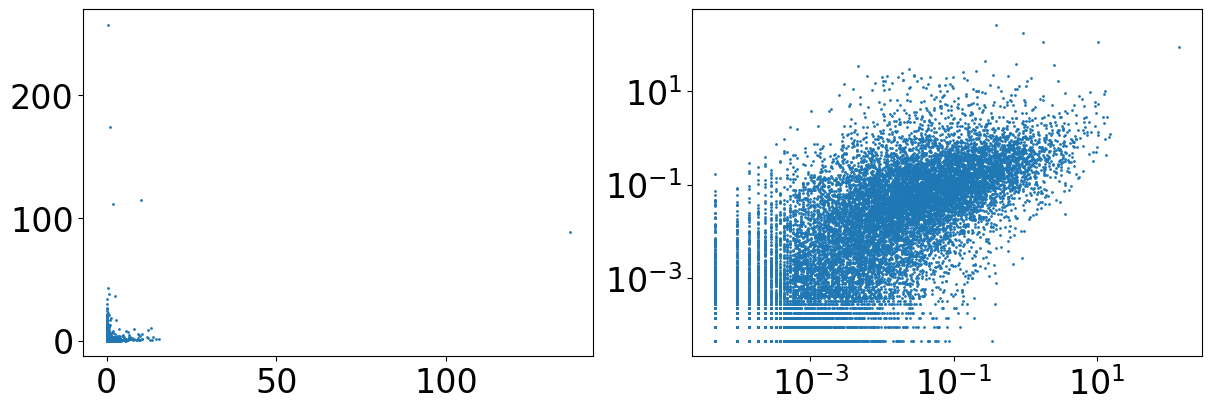

In [10]:
fig, ax = plt.subplots(1,2,figsize=(12,4))
ax[0].scatter(adata.layers['unspliced'].toarray().mean(0),adata.layers['spliced'].toarray().mean(0),s=1)
ax[1].scatter(adata.layers['unspliced'].toarray().mean(0),adata.layers['spliced'].toarray().mean(0),s=1)
ax[1].set_xscale('log')
ax[1].set_yscale('log')
print(adata.layers['unspliced'].toarray().mean(),adata.layers['spliced'].toarray().mean())

In [ ]:
idx = (adata.layers["spliced"].toarray().mean(0) > 0) & (adata.layers["unspliced"].toarray().mean(0) > 0)

U = adata.layers["unspliced"][:,idx].toarray()
n,p = U.shape
X = U
X_cov = np.cov(X,rowvar=False)
X_mean = np.mean(X,axis=0)
X_rho = X_cov/X_mean[:,None]/X_mean[None,:]
su = (np.sum(X_rho)-np.sum(np.diag(X_rho)))/((p-1)*p)
print("s estimated by normalized covariance of total U counts =", str(su))

S = adata.layers["spliced"][:,idx].toarray()
n,p = S.shape
X = S
X_cov = np.cov(X,rowvar=False)
X_mean = np.mean(X,axis=0)
X_rho = X_cov/X_mean[:,None]/X_mean[None,:]
ss = (np.sum(X_rho)-np.sum(np.diag(X_rho)))/((p-1)*p)
print("s estimated by normalized covariance of total S counts =", str(ss))

X = S + U
n,p = X.shape
X_cov = np.cov(X,rowvar=False)
X_mean = np.mean(X,axis=0)
X_rho = X_cov/X_mean[:,None]/X_mean[None,:]
s1 = (np.sum(X_rho)-np.sum(np.diag(X_rho)))/((p-1)*p)
print("s estimated by normalized covariance of total counts =", str(s1))

X_total = X.sum(1)
s2 = (X_total.var()-X_total.mean())/X_total.mean()**2
print("s estimated by total counts =", str(s2))

In [ ]:
a = 1
sp = s1

X_bar = np.mean(X,axis=0)
X_var = np.var(X,axis=0)
for i in range(5):
    Pgene_mask = (X_mean > 0.01) & (X_var/(a*X_mean + sp*X_mean**2) < 1.2)   
    P = (S + U)[:,Pgene_mask]
    n,p = P.shape
    P_cov = np.cov(P,rowvar=False)
    P_mean = np.mean(P,axis=0)
    P_rho = P_cov/P_mean[:,None]/P_mean[None,:]
    sp = (np.sum(P_rho)-np.sum(np.diag(P_rho)))/((p-1)*p)
    print(Pgene_mask.mean(), "s:", str(sp))

0.41046290424857323 s: 0.22195791432942133
0.3824984147114775 s: 0.22914268369117444
0.38446417247939124 s: 0.2287128209719693
0.38446417247939124 s: 0.2287128209719693
0.38446417247939124 s: 0.2287128209719693


Text(0.02, 0.5, 'CV$^2$')

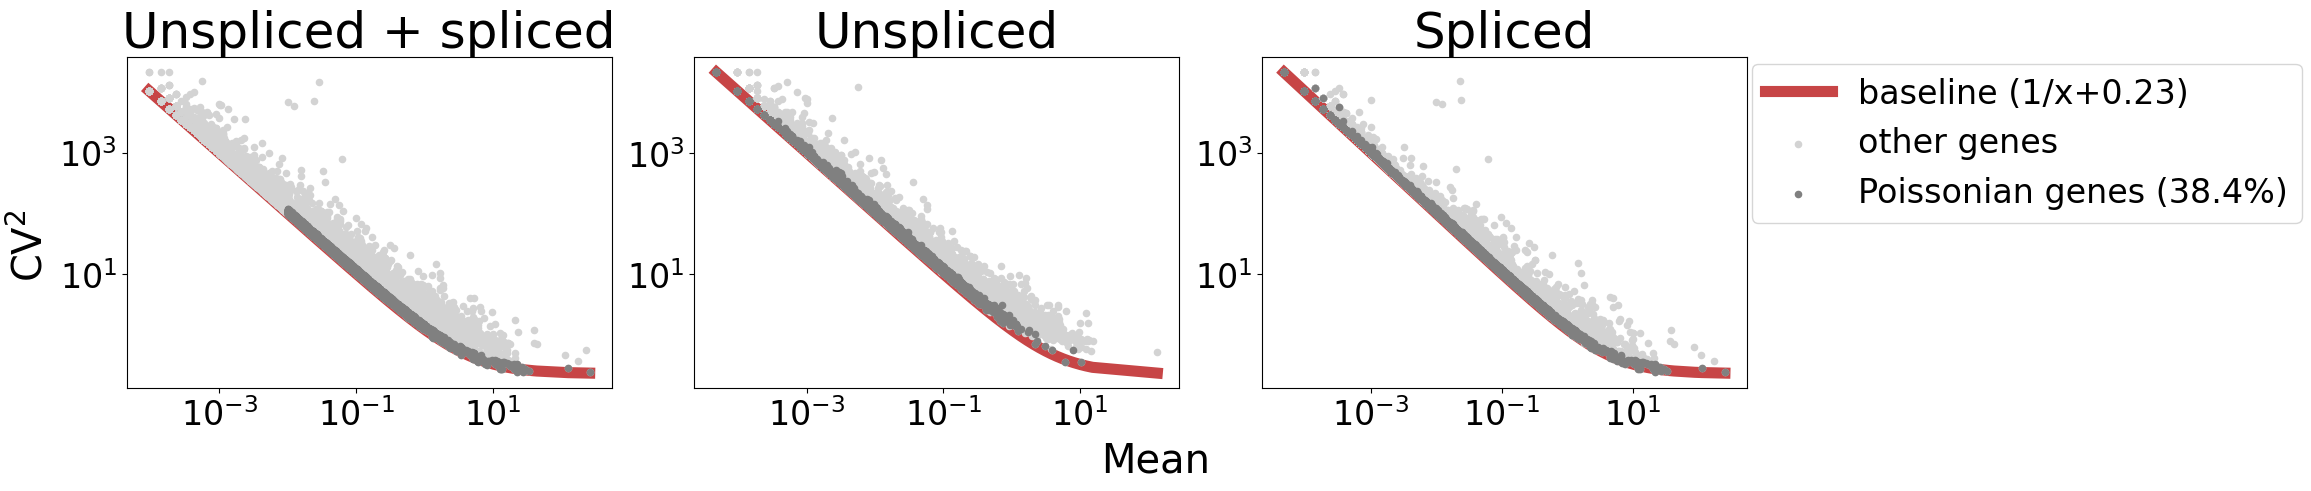

In [ ]:
S_mean = np.mean(S,axis=0)
U_mean = np.mean(U,axis=0)
S_var = np.var(S,axis=0)
U_var = np.var(U,axis=0)

fig, ax = plt.subplots(1,3,figsize=(23,4.8))

ax[0].plot(np.sort(X_mean), a/np.sort(X_mean) + sp, color='#c74546', linewidth=8, zorder=0)
ax[0].scatter(X_mean, X_var/X_mean**2,c='lightgray',alpha=1, s=20)
ax[0].scatter(X_mean[Pgene_mask], X_var[Pgene_mask]/X_mean[Pgene_mask]**2, s=20, c='gray')
ax[0].set_xscale('log')
ax[0].set_yscale('log')
ax[0].set_title('Unspliced + spliced',fontsize=title_font)

ax[1].plot(np.sort(U_mean), a/np.sort(U_mean) + sp, color='#c74546', linewidth=8, zorder=0)
ax[1].scatter(U_mean, U_var/U_mean**2,c='lightgray',alpha=1, s=20, label='other genes')
ax[1].scatter(U_mean[Pgene_mask], U_var[Pgene_mask]/U_mean[Pgene_mask]**2, s=20, c='gray')
ax[1].set_xscale('log')
ax[1].set_yscale('log')
ax[1].set_title('Unspliced',fontsize=title_font)

ax[2].plot(np.sort(S_mean), a/np.sort(S_mean) + sp, color='#c74546', linewidth=8, zorder=0, label='baseline (1/x+'+str(np.around(sp,2))+")")
ax[2].scatter(S_mean, S_var/S_mean**2,c='lightgray',alpha=1, s=20, label='other genes')
ax[2].scatter(S_mean[Pgene_mask], S_var[Pgene_mask]/S_mean[Pgene_mask]**2, s=20, c='gray', label='Poissonian genes ('+str(np.around(100*np.sum(Pgene_mask)/len(X_bar),1))+"%)")
ax[2].set_xscale('log')
ax[2].set_yscale('log')
ax[2].set_title('Spliced',fontsize=title_font)

ax[2].legend(loc=(1.01,0.5),fontsize=legend_font)
fig.supxlabel('Mean')
fig.supylabel(r'CV$^2$')

In [ ]:
clusters = pd.Series(clusters)

In [ ]:
cmap = plt.get_cmap('viridis')
cmap_cluster = [cmap(i) for i in np.linspace(0, 1, len(Clusters))]

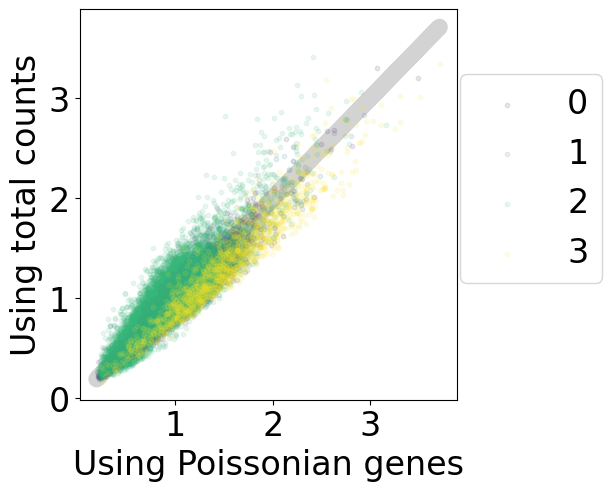

In [ ]:
rd = (U + S)[:, Pgene_mask].mean(1)/(U + S)[:, Pgene_mask].mean()
rd_ = X_total/X_total.mean()
fig, ax = plt.subplots(1, 1, figsize=(6,4.8))
for i, Cluster in enumerate(Clusters):
    idx = clusters.isin([Cluster])
    ax.scatter(rd[idx], rd_[idx], color=cmap_cluster[i], alpha=.1, s=10, label=Cluster)
ax.plot(rd, rd, color='lightgray', zorder=0)
plt.xlabel('Using Poissonian genes', fontsize=legend_font)
plt.ylabel('Using total counts', fontsize=legend_font)
plt.legend(loc=(1.01, 0.3), fontsize=legend_font)

## Select genes

In [ ]:
mapped_features = pd.read_csv("data/janssens_2025_preprint_author_counts_eLNP_RNA_vs_ADT_corrs.csv")

FileNotFoundError: [Errno 2] No such file or directory: 'janssens_2025_preprint_author_counts_eLNP_RNA_vs_ADT_corrs.csv'

In [ ]:
np.percentile(mapped_features['Mean_RNA_expr'], 50)

np.float64(0.0097265584794318)

In [33]:
a = 1
var_threshold = 1.5

U_mean = adata.layers["unspliced"].toarray().mean(0)
S_mean = adata.layers["spliced"].toarray().mean(0)
U_var = adata.layers["unspliced"].toarray().var(0)
S_var = adata.layers["spliced"].toarray().var(0)

fitted_idx = np.where((U_mean > 0.02) & (S_mean > 0.1) \
    & (U_var/(a*U_mean + sp*U_mean**2) > var_threshold) \
    & (S_var/(a*S_mean + sp*S_mean**2) > var_threshold) \
    & (np.abs(np.log(S_mean/U_mean)) < 4))

/tmp/ipykernel_346124/1669863792.py:10: RuntimeWarning: invalid value encountered in divide
  & (U_var/(a*U_mean + sp*U_mean**2) > var_threshold) \
/tmp/ipykernel_346124/1669863792.py:11: RuntimeWarning: invalid value encountered in divide
  & (S_var/(a*S_mean + sp*S_mean**2) > var_threshold) \
/tmp/ipykernel_346124/1669863792.py:12: RuntimeWarning: divide by zero encountered in divide
  & (np.abs(np.log(S_mean/U_mean)) < 4))
/tmp/ipykernel_346124/1669863792.py:12: RuntimeWarning: invalid value encountered in divide
  & (np.abs(np.log(S_mean/U_mean)) < 4))
/tmp/ipykernel_346124/1669863792.py:12: RuntimeWarning: divide by zero encountered in log
  & (np.abs(np.log(S_mean/U_mean)) < 4))


In [ ]:
mapped_features_hi = mapped_features.loc[mapped_features['Mean_RNA_expr'] > 0.2]
mapped_features_idx = np.where(adata.var_names.isin(mapped_features_hi['Gene'].tolist()))
all_idx = np.sort(np.unique(np.concat([mapped_features_idx[0], fitted_idx[0]])))

fitted_genes = adata.var_names[all_idx]
print(fitted_genes)

Index(['Tmem131', 'Nabp1', 'Stk17b', 'Cxcr4', 'Ptprc', 'Ifi207', 'Ifi205',
       'Atf3', 'Map4k4', 'Icos',
       ...
       'Atp1b3', 'Rasa2', 'Xcr1', 'Tmem123', 'Icam1', 'Vwa5a', 'Jaml',
       'Dscaml1', 'Anxa2', 'Gclc'],
      dtype='object', name='Gene', length=208)


In [83]:
pd.DataFrame(fitted_genes.tolist(), columns=["Gene_symbol"])

,Gene_symbol
0,Tmem131
1,Nabp1
2,Stk17b
3,Cxcr4
4,Ptprc
...,...
203,Vwa5a
204,Jaml
205,Dscaml1
206,Anxa2


In [84]:
fitted_genes_df = pd.DataFrame(fitted_genes.tolist(), columns=["Gene_symbol"])

fitted_genes_df.to_csv(f"eLNPs_var>1.5_{len(fitted_genes)}_genes.csv", index=False)

Ref: https://www.science.org/doi/10.1126/sciimmunol.add3955

CD207 and CD103 were up-regulated during the transition from early immature to late immature cDC1s

Also: see Fig. 2b

- ...early committed cDC1s underwent cell cycle proliferation in situ (“proliferating cDC1s”), as revealed by the expression of cell cycle genes that allowed us to assign cells to the G1, S, or G2-M phase
- During the transition from early immature cDC1s to late immature cDC1s ... the top gene that marked the transition from early to late immature cDC1s was Apol7c, an apolipoprotein with unknown function. In addition, Apoe, a well-established mediator of cholesterol efflux, was increased in expression, whereas Fdps, a rate-limiting enzyme for cholesterol biosynthesis, decreased in expression between early to late immature cDC1s.
- Other genes that marked the transition from early to late immature cDC1s were a group of nuclear receptor proteins (Nr4a2 and Nr4a3) and some early response genes (Egr3 and Egr2; Fig. 3, A and B, and fig. S5C). ... EGR and NR4A proteins have been proposed to be negative regulators of DC immunogenicity.
- Dnase1l3, which encodes an enzyme required for degrading self-DNA from ACs and associated with autoimmunity (63), was up-regulated in late immature cDC1s
- The transition from late immature to early mature cDC1s was characterized by induction of IFN-inducible genes such as Cxcl10, Cxcl9, Iigp1, Ifi47, Gbp2, and Gbp5
- ...the transition to late mature cDC1s was characterized by the expression of several well-established markers such as Cd63, Fscn1, Il4i1, or Socs2

/tmp/ipykernel_346124/3805144832.py:3: RuntimeWarning: invalid value encountered in divide
  ax[0].scatter(S_mean, S_var/S_mean**2,c='lightgray',alpha=1, s=10)
/tmp/ipykernel_346124/3805144832.py:4: RuntimeWarning: divide by zero encountered in divide
  ax[0].scatter(S_mean, a/S_mean + sp, c='#c74546', alpha=0.5, s=20)
/tmp/ipykernel_346124/3805144832.py:11: RuntimeWarning: invalid value encountered in divide
  ax[1].scatter(U_mean, U_var/U_mean**2,c='lightgray',alpha=1, s=10, label='other genes')
/tmp/ipykernel_346124/3805144832.py:12: RuntimeWarning: divide by zero encountered in divide
  ax[1].scatter(U_mean, a/U_mean + sp, c='#c74546', alpha=0.5, s=20, label='variance baseline')


Text(0.02, 0.5, 'Variance')

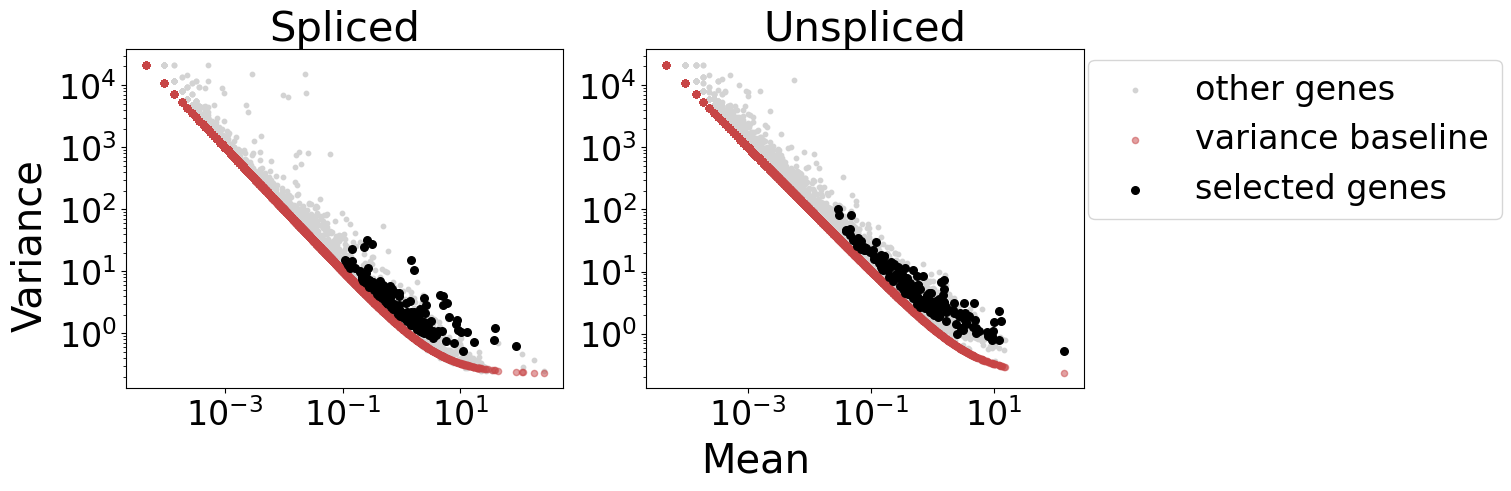

In [55]:
fig, ax = plt.subplots(1,2,figsize=(15,4.8))

ax[0].scatter(S_mean, S_var/S_mean**2,c='lightgray',alpha=1, s=10)
ax[0].scatter(S_mean, a/S_mean + sp, c='#c74546', alpha=0.5, s=20)
ax[0].scatter(S_mean[fitted_idx], S_var[fitted_idx]/S_mean[fitted_idx]**2, s=30, c='k')
ax[0].set_xscale('log')
ax[0].set_yscale('log')
ax[0].set_title('Spliced',fontsize=label_font)


ax[1].scatter(U_mean, U_var/U_mean**2,c='lightgray',alpha=1, s=10, label='other genes')
ax[1].scatter(U_mean, a/U_mean + sp, c='#c74546', alpha=0.5, s=20, label='variance baseline')
ax[1].scatter(U_mean[fitted_idx], U_var[fitted_idx]/U_mean[fitted_idx]**2, s=30, c='k', label='selected genes')
ax[1].set_xscale('log')
ax[1].set_yscale('log')
ax[1].legend(loc=(1.01,0.5),fontsize=legend_font)
ax[1].set_title('Unspliced',fontsize=label_font)
fig.supxlabel('Mean')
fig.supylabel('Variance')

In [56]:
# Subset expression data to fitted genes

X=np.zeros((adata.n_obs,len(all_idx),2))
X[:,:,0]=adata.layers["unspliced"][:,all_idx].toarray()
X[:,:,1]=adata.layers["spliced"][:,all_idx].toarray()
fitted_genes=adata.var_names[all_idx]
print(X[:,:,0].mean(),X[:,:,1].mean())
X.shape

2.007931057805032 2.3562160699792587


(21325, 208, 2)

## Mixtures fitting

In [57]:
Clusters = set(clusters)
cell_idx = clusters.isin(Clusters)
X_mix = X[cell_idx]

1 -786.3324283050077 -786.3519359251719 -786.429650727397
2 -630.029152293243 -630.0584606168069 -630.175219634573
3 -606.8469136993349 -606.8860227262985 -607.0418259596056
4 -581.4944149365759 -581.5433246669394 -581.7381721157875
5 -576.5053377172761 -576.5640481510393 -576.7979398154284
6 -572.0128885388689 -572.0813996760319 -572.3543355559619


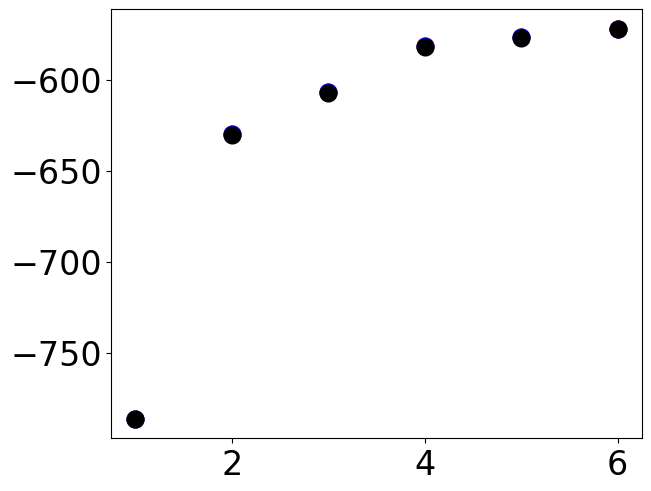

In [58]:
PMs = []
for nc in range(1,7):
    PM = PoissonMixtureSS(n_components=nc,verbose=0)
    Q, elbo = PM.fit(X_mix, warm_start=False, read_depth=rd, epoch=5, n_init=3)
    PMs.append(PM)
    plt.scatter(nc,elbo,color='r')
    plt.scatter(nc,PM.compute_AIC(X_mix),color='b')
    plt.scatter(nc,PM.compute_BIC(X_mix),color='k')
    print(nc,PM.compute_lower_bound(X_mix), PM.compute_AIC(X_mix), PM.compute_BIC(X_mix))

In [ ]:
# n_ctypes = adata.obs.value_counts("newClustersTmp").values

# Q0 = n_ctypes / n_ctypes.sum()

In [59]:
PM = PoissonMixtureSS(n_components=4, verbose=0)
Q, elbo = PM.fit(X, warm_start=False, read_depth=rd, epoch=10, n_init=10)
PM.Q = Q
PM.elbo = elbo
PM.weights

array([0.27291272, 0.26125325, 0.23183894, 0.2339951 ])

(np.float64(-581.2761715706964),
 array([0.27291272, 0.26125325, 0.23183894, 0.2339951 ]))

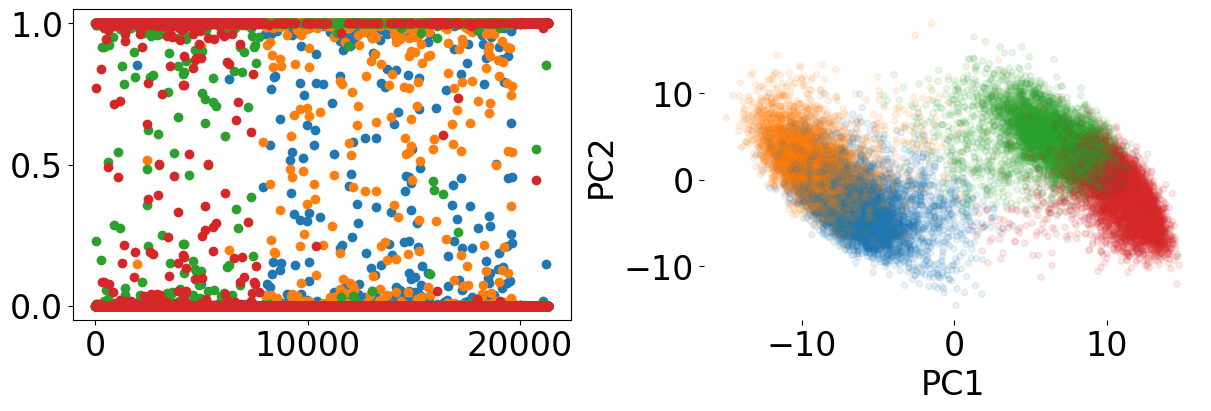

In [60]:
tab_colors = plt.cm.tab10(np.arange(10))
fig, ax = plt.subplots(1, 2, figsize=(12,4))
ax[0].plot(Q[np.argsort(clusters)], '.');
ax[1].scatter(x[:, 0], x[:, 1], c=tab_colors[np.argmax(Q,axis=-1)], s=20, alpha=.1);
ax[1].set_xlabel('PC1', fontsize=24)
ax[1].set_ylabel('PC2', fontsize=24)
ax[1].set_frame_on(False)

elbo, PM.weights

In [ ]:
# # Calculate the two components of log likelihood
# cluster_gene_logL, cluster_KL = PM.compute_gene_logL(X, Q)
# cluster_KL 

np.float64(-1.3778012483619089)

## Trajectory fitting

### Warm start

In [61]:
# Assign each cell a probability of being in a given state

m = 100
cell_types = ["Proliferating cDC1s", "Immature cDC1s", "Early mature cDC1s", "Late mature cDC1s"]

weight0 = np.zeros((adata.n_obs, m))
for i, cell_type in enumerate(cell_types):
    idx = adata.obs['newClustersTmp'].isin([cell_type])
    weight0[idx, int(i*m/len(cell_types)):int((i+1)*m/len(cell_types))] += 1

weight0 = weight0 / weight0.sum(axis=1, keepdims=True)
Q0 = weight0[:, None]

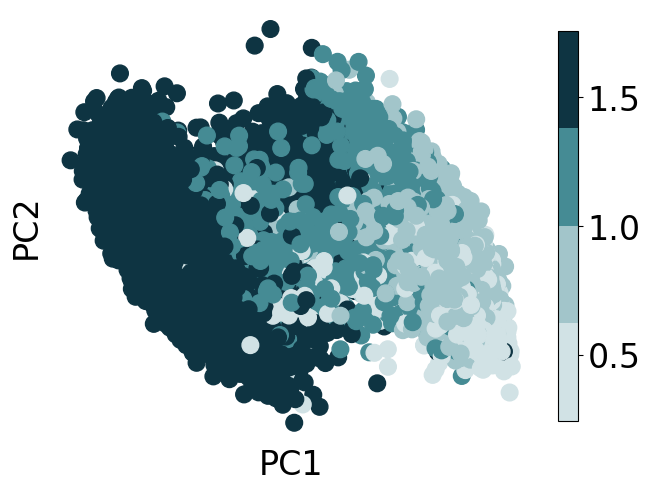

In [62]:
from matplotlib.colors import LinearSegmentedColormap

color_palette = ["#d1e2e5","#BAD4D8","#a2c5ca","#74A8AF","#458b94","#2a606b","#0e3442"]
cmap_teal = LinearSegmentedColormap.from_list("Teals", color_palette, N=len(cell_types))

ref_t = weight0@(np.linspace(0, 2, m).reshape((-1, 1)))
cmap_y = cmr.get_sub_cmap('Blues', 0.2, 1)
fig, ax = plt.subplots(1, 1)
im = ax.scatter(x[:, 0], x[:, 1], c=ref_t, cmap=cmap_teal);
ax.set_xlabel('PC1', fontsize=24)
ax.set_ylabel('PC2', fontsize=24)
ax.set_frame_on(False)
plt.xticks([]);
plt.yticks([]);
plt.colorbar(im, fraction=0.05, shrink=0.9) # adding the colobar on the right

In [63]:
# Note: θ = (α0, ..., α_n, β, γ, τ)
# Transcription rates (one per state)	

n = len(Clusters)

traj_params={'r':rd, "lambda_tau":0, "lambda_a":0}
topo = np.array([np.array(list(range(0, n)))], dtype=int)
tau = np.linspace(0, 8, n)  # Generates initial switching times between each trajectory
tau

array([0.        , 2.66666667, 5.33333333, 8.        ])

In [64]:
traj = Trajectory(topo, tau, model="two_species_ss", verbose=1)
# traj = traj.fit(X, warm_start=False, fit_tau=True, params=traj_params, Q=None, parallel=True, n_threads=20, epoch=30, n_init=3)
traj = traj.fit(X, warm_start=True, fit_tau=True, params=traj_params, Q=Q0, parallel=True, n_threads=20, epoch=20, n_init=3)

fitting with warm start


100%|██████████| 20/20 [02:38<00:00,  7.91s/it]


In [70]:
import pickle
with open(f"eLNPs_var>1.5_{len(fitted_genes)}_genes_traj_WS.pkl", "wb") as f:
    pickle.dump(traj, f, protocol=pickle.HIGHEST_PROTOCOL)

-584.6091602879313


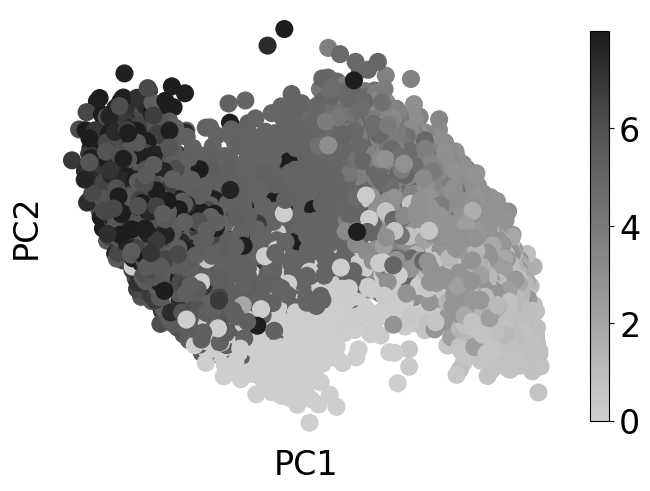

In [46]:
print(traj.elbos[-1])
t_hat = traj.Q.sum(1)@traj.t
cmap_y = cmr.get_sub_cmap('Greys', 0.3, 0.9)
fig, ax = plt.subplots(1,1)
im = ax.scatter(x[:,0], x[:,1], c=t_hat, cmap=cmap_y);
ax.set_xlabel('PC1', fontsize=24)
ax.set_ylabel('PC2', fontsize=24)
ax.set_frame_on(False)
plt.xticks([]);
plt.yticks([]);
plt.colorbar(im, fraction=0.05, shrink=0.9) # adding the colobar on the right

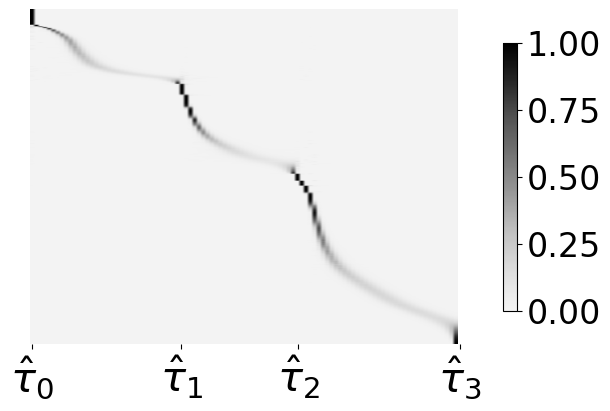

In [65]:
fig, ax = plt.subplots(1,1,figsize=(6,4))
cmap_Q = cmr.get_sub_cmap('Greys', 0.1, 1)

order = np.argsort(traj.Q[:,0]@traj.t)
im = ax.imshow(traj.Q.sum(1)[order],aspect="auto",cmap=cmap_Q);
plt.colorbar(im,fraction=0.2, shrink =0.8) # adding the colobar on the right
x_label_list = [r'$\hat{\tau}_0$', r'$\hat{\tau}_1$', r'$\hat{\tau}_2$', r'$\hat{\tau}_3$']
ax.set_xticks(traj.m*traj.tau/traj.tau[-1])
ax.set_xticklabels(x_label_list,fontsize=30)
ax.set_yticks([])
for spine in ['top', 'right', 'left', 'bottom']:
    ax.spines[spine].set_visible(False)

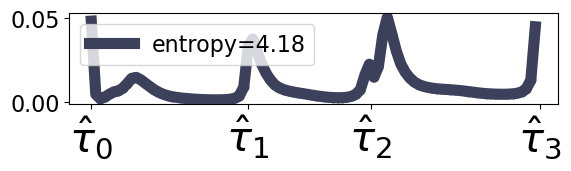

In [66]:
from scipy.stats import pearsonr, spearmanr, norminvgauss, invgauss, expon, entropy

plt.rcParams['font.size'] = '16'
fig,ax = plt.subplots(figsize=(5.6,1.6))
ax.plot(traj.Q.sum((0,1))/traj.Q.sum(),'.-',color="#3d405b",linewidth=8,\
        label="entropy="+str(np.around(entropy(traj.Q.sum((0,1))/traj.Q.sum()),2)));
x_label_list = [r'$\hat{\tau}_0$', r'$\hat{\tau}_1$', r'$\hat{\tau}_2$', r'$\hat{\tau}_3$']
ax.set_xticks(traj.m*traj.tau/traj.tau[-1])
ax.set_xticklabels(x_label_list,fontsize=30)
#ax.set_xticklabels(x_label_list)
#ax.set_xlabel('Process time',fontsize=24)
#ax.set_ylabel('Probability mass',fontsize=24)
ax.legend()
plt.rcParams['font.size'] = '24'

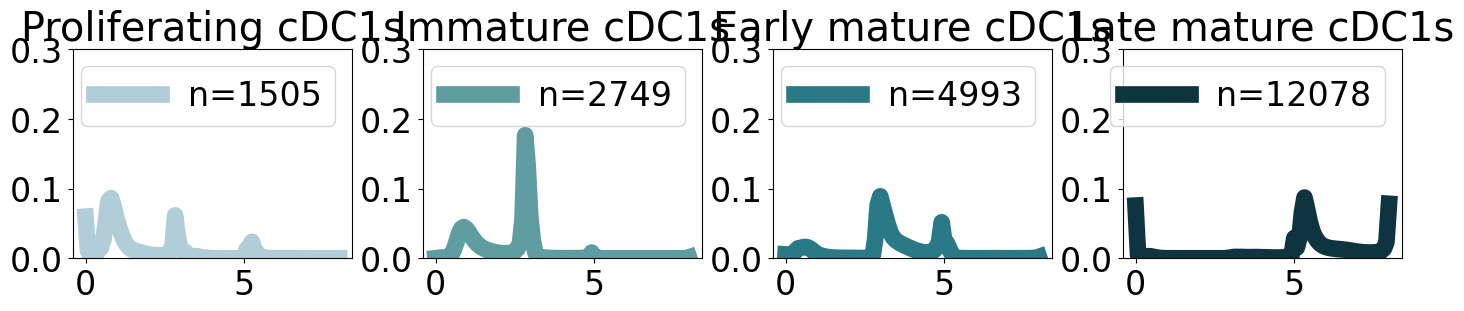

In [67]:
stages = ["Proliferating cDC1s", "Immature cDC1s", "Early mature cDC1s", "Late mature cDC1s"]
color_palette = ["#b1cdd8","#5f9da2","#2a7986","#0e3442"]
timepoint_cmp = LinearSegmentedColormap.from_list("my_cmap", color_palette, N=len(stages))

fig, ax = plt.subplots(1,len(stages),figsize=(3.5*len(stages),3))
for i,stage in enumerate(stages):
    idx = adata.obs["newClustersTmp"].isin([stage])
    ax[i].plot(traj.t, traj.Q[idx,0].mean(0),'.-',label="n="+str(idx.sum()),color=timepoint_cmp(i))
    ax[i].set_title(stage)
    ax[i].set_ylim((0,0.3))
    ax[i].legend()

Text(0, 0.5, 'Explained variance')

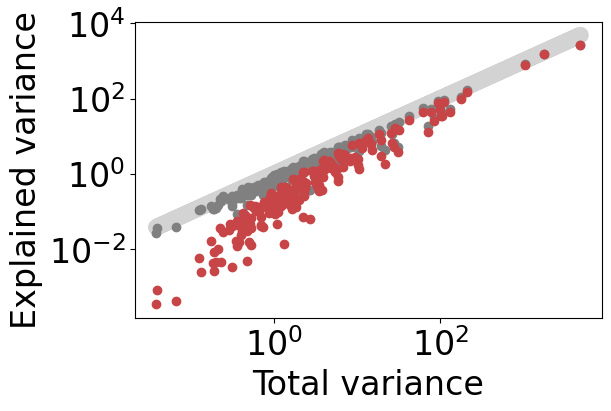

In [68]:
Y_grid = traj.get_Y_hat(traj.theta, traj.t, traj.tau, traj.topo, traj.params)[0]
Y = traj.params['r'][:,None,None] * np.sum(traj.Q[:,:,:,None,None]* Y_grid[None,:],axis=(1,2)) 

mean = X[:,:,1].mean(axis=0)
var = X[:,:,1].var(axis=0)
Y_mean = Y[:,:,1].mean(axis=0)
Y_var = Y[:,:,1].var(axis=0)

fig, ax = plt.subplots(1,1,figsize=(6,4))
plt.loglog(var,var,color='lightgray')
plt.loglog(var,Y_var+Y_mean,'.',color='gray')
plt.loglog(var,Y_var,'.',color='#c74546')
plt.xlabel('Total variance')
plt.ylabel('Explained variance')

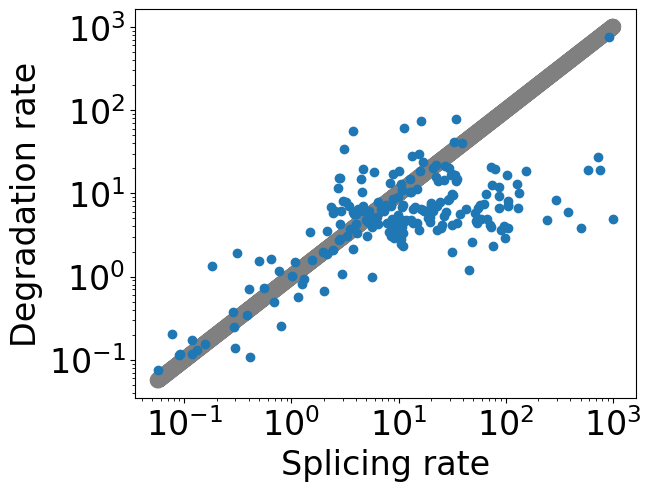

In [69]:
plt.loglog(traj.theta[:,[-2]],traj.theta[:,[-2]],'-',color='gray');
plt.loglog(traj.theta[:,[-2]],traj.theta[:,[-1]],'.');
plt.xlabel("Splicing rate");
plt.ylabel("Degradation rate");

In [80]:
import dill
dill.dump_session('Chronocell_eLNPs_var>1.5_ADT_genes_env.db')

# Plots below corresponds to Chronocell_eLNPs_var>1.2_env

In [ ]:
import os, sys

os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ.setdefault("NUMEXPR_NUM_THREADS", "1")
os.environ.setdefault("VECLIB_MAXIMUM_THREADS", "1")

sys.path.append("/mnt/lareaulab/reliscu/programs/FGP_2024")

import Chronocell
from Chronocell.inference import Trajectory
from Chronocell.mixtures import PoissonMixtureSS
from Chronocell.utils import *
from Chronocell.plotting import *
import scipy.stats as stats
from scipy.interpolate import UnivariateSpline, RBFInterpolator
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cmasher as cmr
from tqdm import tqdm
import copy
import anndata as ad

os.chdir("/mnt/lareaulab/reliscu/projects/Chronocell/analyses/janssens_2025_preprint")

import dill
dill.load_session('Chronocell_eLNPs_var>1.5_shared_genes_env.db')

In [ ]:
# # Running on compute2

# from multiprocessing import Pool

# n = len(Clusters)

# params = {'r':rd, "lambda_tau":0, "lambda_a":0} # lambdas are L2 regularization coefficients
# topo = np.array([np.array(list(range(0, n)))], dtype=int)
# tau = np.linspace(0, 8, n)

# Input_args = []
# def fit_wrapper(seed):
#     traj = Trajectory(topo, tau, model="two_species_ss", verbose=0)
#     traj = traj.fit(X, m=100, n_init=1, params=params, perm_theta=False, epoch=20, parallel=False, n_threads=1, seed=seed)
#     return traj
    
# for seed in range(50):
#     Input_args.append([seed])
            
# with Pool(20) as pool:     
#     trajs = pool.starmap(fit_wrapper, Input_args, chunksize=1)

In [ ]:
corrs = []
AICs = []
right_t = Q0[:, 0] @ traj.t
for traj in trajs:
    t_hat = traj.Q[:, 0] @ traj.t
    corrs.append(pearsonr(right_t, t_hat)[0])
    AICs.append(traj.compute_AIC(traj.X, standard=True))

In [9]:
np.min(AICs)

np.float64(61888381.9165295)

In [ ]:
# trajs_ = trajs
# for traj_ in trajs_:
#     if "X" in traj_.__dict__.keys(): 
#         delattr(traj_, "X")

# import pickle
# with open("eLNPs_var>1.2_trajs.pkl", "wb") as f:
#     pickle.dump(trajs_, f, protocol=pickle.HIGHEST_PROTOCOL)
    
# with open("eLNPs_var>1.2_corrs.pkl", "wb") as f:
#     pickle.dump(corrs, f, protocol=pickle.HIGHEST_PROTOCOL)

# with open("eLNPs_var>1.2_AICs.pkl", "wb") as f:
#     pickle.dump(AICs, f, protocol=pickle.HIGHEST_PROTOCOL)

In [ ]:
import os, sys

os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ.setdefault("NUMEXPR_NUM_THREADS", "1")
os.environ.setdefault("VECLIB_MAXIMUM_THREADS", "1")

sys.path.append("/mnt/lareaulab/reliscu/programs/FGP_2024")

import Chronocell
from Chronocell.inference import Trajectory
from Chronocell.mixtures import PoissonMixtureSS
from Chronocell.utils import *
from Chronocell.plotting import *
import scipy.stats as stats
from scipy.interpolate import UnivariateSpline, RBFInterpolator
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cmasher as cmr
from tqdm import tqdm
import copy
import anndata as ad

os.chdir("/mnt/lareaulab/reliscu/projects/Chronocell/analyses/janssens_2025_preprint")

import dill
dill.load_session('Chronocell_eLNPs_var>1.2_env.db')

In [2]:
with open("eLNPs_var>1.2_trajs.pkl", "rb") as f:
    trajs = pickle.load(f)

with open("eLNPs_var>1.2_corrs.pkl", "rb") as f:
    corrs = pickle.load(f)

with open("eLNPs_var>1.2_AICs.pkl", "rb") as f:
    AICs = pickle.load(f)

In [ ]:
from sklearn.metrics import average_precision_score, precision_recall_curve

corr_thresh = 0.5

is_correct_direction = np.array(np.array(corrs) > corr_thresh, dtype=bool)
corrs_ratio = np.mean(is_correct_direction)
precision, recall, thresholds = precision_recall_curve(y_true=is_correct_direction, probas_pred=-np.array(AICs))
score = average_precision_score(y_true=is_correct_direction, y_score=-np.array(AICs))
plt.plot(recall, precision,'-', color='#3975b5', alpha=0.75, label="Average precision="+str(np.around(score,2)))
plt.ylim([-0.1, 1.1])
plt.legend(fontsize=20)

In [ ]:
plt.hist(corrs)

In [ ]:
fig, ax = plt.subplots(1,1,figsize=(10,4.8))
plt.scatter(corrs,np.array(AICs),s=1000,marker='.',color='#3975b5',alpha=0.5,label='random init\nAP='+str(np.around(score,2)))
plt.axhline(traj.compute_AIC(traj.X, standard=True),linewidth=12,zorder=0,color='#c74546',alpha=0.5,label='warm start')
plt.axhline(PM.compute_AIC(traj.X, standard=True),color='#dca36a',linewidth=12,zorder=0,alpha=0.5,label='3 clusters')
#ax.set_yticks([])
ax.set_xlim([-1.1,1.1])
plt.legend(loc=(1.01,0.5),fontsize=legend_font)
#plt.title('ELBO of different initialiazations',fontsize=30

In [ ]:
# # conda activate chronocell

# import os
# import sys

# sys.path.append("/mnt/lareaulab/reliscu/programs/FGP_2024")

# import Chronocell
# from Chronocell.inference import Trajectory
# from Chronocell.mixtures import PoissonMixtureSS
# from Chronocell.utils import *
# from Chronocell.plotting import *
# import scipy.stats as stats
# from scipy.interpolate import UnivariateSpline, RBFInterpolator
# import scanpy as sc
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# import cmasher as cmr
# from tqdm import tqdm
# import copy
# import anndata as ad

# os.chdir("/mnt/lareaulab/reliscu/projects/Chronocell/analyses/janssens_2025_preprint")

# import dill
# dill.load_session('Chronocell_eLNPs_var>1.2_env.db')